In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
## 1. Setup Paths & Configuration

import sys
import os
from pathlib import Path

# Add source directory to path
current_path = Path.cwd()
base_project_dir = current_path.parent
src_dir = base_project_dir / "src"

if str(src_dir) not in sys.path:
    sys.path.append(str(src_dir))

# Define key directories
dataset_directory = src_dir / "abstractionsshapecoder" / "dataset"
saved_directory = src_dir / "abstractionsshapecoder" / "saved"

# --- AE Model Paths ---
saved_models_L1_AE_dir = saved_directory / "models_L1_AE"
saved_models_L2_AE_dir = saved_directory / "models_L2_AE"
saved_models_L1_AE_dir.mkdir(parents=True, exist_ok=True)
saved_models_L2_AE_dir.mkdir(parents=True, exist_ok=True)

# --- PCA Model Paths ---
saved_models_L1_PCA_dir = saved_directory / "models_L1_PCA"
saved_models_L2_PCA_dir = saved_directory / "models_L2_PCA"
saved_models_L1_PCA_dir.mkdir(parents=True, exist_ok=True)
saved_models_L2_PCA_dir.mkdir(parents=True, exist_ok=True)

print(f"Base project directory: {base_project_dir}")
print(f"Source directory: {src_dir}")
print(f"L1 AE Models directory: {saved_models_L1_AE_dir}")
print(f"L2 AE Models directory: {saved_models_L2_AE_dir}")
print(f"L1 PCA Models directory: {saved_models_L1_PCA_dir}")
print(f"L2 PCA Models directory: {saved_models_L2_PCA_dir}")

Base project directory: c:\Users\Amogh\abstraction-discovery
Source directory: c:\Users\Amogh\abstraction-discovery\src
L1 AE Models directory: c:\Users\Amogh\abstraction-discovery\src\abstractionsshapecoder\saved\models_L1_AE
L2 AE Models directory: c:\Users\Amogh\abstraction-discovery\src\abstractionsshapecoder\saved\models_L2_AE
L1 PCA Models directory: c:\Users\Amogh\abstraction-discovery\src\abstractionsshapecoder\saved\models_L1_PCA
L2 PCA Models directory: c:\Users\Amogh\abstraction-discovery\src\abstractionsshapecoder\saved\models_L2_PCA


In [5]:
import pickle
from pathlib import Path
from abstractionsshapecoder.debug_utils import debug_info, debug_success, debug_error

def load_processed_datasets():
    """
    Loads all hierarchical datasets (L0, L1-VAE, L1-AE, L2-AE) from the saved directory.
    """
    SAVED_DIR = Path.cwd().parent / "src" / "abstractionsshapecoder" / "saved"
    
    # Define file map: {Variable_Name: Filename}
    dataset_files = {
        "shapes_l0": "all_dsl_shapes.pkl",
        "shapes_l1_vae": "all_abstracted_shapes_L1_VAE.pkl",
        "shapes_l1_ae": "all_abstracted_shapes_L1_AE.pkl",
        "shapes_l2_ae": "all_abstracted_shapes_L2_AE.pkl"
    }
    
    loaded_datasets = {}
    
    for var_name, filename in dataset_files.items():
        file_path = SAVED_DIR / filename
        if file_path.exists():
            debug_info(f"Loading {var_name} from {filename}...")
            with open(file_path, "rb") as f:
                loaded_datasets[var_name] = pickle.load(f)
            debug_success(f"Successfully loaded {len(loaded_datasets[var_name])} shapes into {var_name}.")
        else:
            debug_error(f"Missing file: {filename}. Ensure previous training cells were run.")
            loaded_datasets[var_name] = {}
            
    return loaded_datasets

# Execute the load
datasets = load_processed_datasets()

# Extract into global namespace for easier access in subsequent cells
shapes_l0 = datasets.get("shapes_l0")

[INFO] Loading shapes_l0 from all_dsl_shapes.pkl...
[SUCCESS] Successfully loaded 1100 shapes into shapes_l0.
[INFO] Loading shapes_l1_vae from all_abstracted_shapes_L1_VAE.pkl...
[SUCCESS] Successfully loaded 1100 shapes into shapes_l1_vae.
[ERROR] Missing file: all_abstracted_shapes_L1_AE.pkl. Ensure previous training cells were run.
[ERROR] Missing file: all_abstracted_shapes_L2_AE.pkl. Ensure previous training cells were run.


In [7]:
shapes_l0["172_0_0"]

{'dsl': <abstractionsshapecoder.dsl_nodes.Union at 0x271b37ee990>,
 'singleton_params': {'Cuboid': [[0.68, 0.09, 0.66],
   [0.06, 0.6, 0.06],
   [0.06, 0.6, 0.06],
   [0.06, 0.6, 0.06],
   [0.06, 0.6, 0.06],
   [0.08, 0.79, 0.08],
   [0.08, 0.79, 0.08],
   [0.68, 0.14, 0.24],
   [0.08, 0.79, 0.08],
   [0.08, 0.79, 0.08],
   [0.08, 0.79, 0.08]],
  'Translate': [[-0.0, -0.17, 0.0],
   [-0.31, -0.51, -0.17],
   [-0.31, -0.51, 0.3],
   [0.31, -0.51, -0.17],
   [0.31, -0.51, 0.3],
   [-0.26, 0.27, -0.18],
   [-0.14, 0.27, -0.25],
   [0.0, 0.74, -0.22],
   [-0.0, 0.27, -0.25],
   [0.14, 0.27, -0.25],
   [0.28, 0.27, -0.25]]},
 'pair_params': {'Translate(Cuboid)': [[-0.0, -0.17, 0.0, 0.68, 0.09, 0.66],
   [-0.31, -0.51, -0.17, 0.06, 0.6, 0.06],
   [-0.31, -0.51, 0.3, 0.06, 0.6, 0.06],
   [0.31, -0.51, -0.17, 0.06, 0.6, 0.06],
   [0.31, -0.51, 0.3, 0.06, 0.6, 0.06],
   [-0.26, 0.27, -0.18, 0.08, 0.79, 0.08],
   [-0.14, 0.27, -0.25, 0.08, 0.79, 0.08],
   [0.0, 0.74, -0.22, 0.68, 0.14, 0.24],
  

In [8]:
from abstractionsshapecoder.dsl_utils import collect_singleton_and_pair_data
from abstractionsshapecoder.debug_utils import debug_info, debug_success

# 1. Isolate the DSL objects from the dictionary
all_l0_dsl_trees = [data['dsl'] for data in shapes_l0.values()]

debug_info(f"Extracting parameters from {len(all_l0_dsl_trees)} L0 shapes...")

# 2. Run the collection utility
# s_data_l0: { 'NodeName': [ [params], [params], ... ] }
# p_data_l0: { 'Parent(Child)': [ [params], [params], ... ] }
s_data_l0, p_data_l0 = collect_singleton_and_pair_data(all_l0_dsl_trees)

debug_success(f"Extraction complete.")
debug_info(f"Unique Singletons found: {len(s_data_l0)}")
debug_info(f"Unique Parent-Child Pairs found: {len(p_data_l0)}")

[INFO] Extracting parameters from 1100 L0 shapes...
[SUCCESS] Extraction complete.
[INFO] Unique Singletons found: 3
[INFO] Unique Parent-Child Pairs found: 5


In [10]:
import pandas as pd

# Create a summary for Singletons
singleton_summary = []
for node_type, param_list in s_data_l0.items():
    singleton_summary.append({
        "Node Type": node_type,
        "Total Occurrences": len(param_list),
        "Param Dimension": len(param_list[0]) if param_list else 0,
        "Example Params": param_list[0] if param_list else []
    })

# Create a summary for Pairs
pair_summary = []
for pair_name, param_list in p_data_l0.items():
    pair_summary.append({
        "Relationship": pair_name,
        "Total Occurrences": len(param_list),
        "Combined Dimension": len(param_list[0]) if param_list else 0
    })

# Convert to DataFrames for easy viewing
df_singletons = pd.DataFrame(singleton_summary).sort_values("Total Occurrences", ascending=False)
df_pairs = pd.DataFrame(pair_summary).sort_values("Total Occurrences", ascending=False)

print("=== L0 SINGLETON CENSUS ===")
display(df_singletons)

print("\n=== L0 PAIR CENSUS ===")
display(df_pairs)

=== L0 SINGLETON CENSUS ===


,Node Type,Total Occurrences,Param Dimension,Example Params
0,Cuboid,10268,3,"[0.68, 0.09, 0.66]"
2,Translate,10268,3,"[-0.0, -0.17, 0.0]"
1,Rotate,3416,4,"[-0.17410813759359595, 0.0, 0.0, 0.98472653890..."



=== L0 PAIR CENSUS ===


,Relationship,Total Occurrences,Combined Dimension
2,Translate(Cuboid),10268,6
4,Union(Translate),8656,3
0,Rotate(Rotate),1804,8
1,Rotate(Translate),1612,7
3,Union(Rotate),1612,4


In [15]:
s_data_l0["Cuboid"]

[[0.68, 0.09, 0.66],
 [0.06, 0.6, 0.06],
 [0.06, 0.6, 0.06],
 [0.06, 0.6, 0.06],
 [0.06, 0.6, 0.06],
 [0.08, 0.79, 0.08],
 [0.08, 0.79, 0.08],
 [0.68, 0.14, 0.24],
 [0.08, 0.79, 0.08],
 [0.08, 0.79, 0.08],
 [0.08, 0.79, 0.08],
 [0.88, 0.19, 1.01],
 [0.88, 0.85, 0.31],
 [0.15, 0.52, 0.2],
 [0.21, 0.53, 0.19],
 [0.15, 0.52, 0.2],
 [0.21, 0.53, 0.19],
 [0.92, 0.34, 0.92],
 [0.92, 0.79, 0.49],
 [0.12, 0.42, 0.12],
 [0.14, 0.45, 0.13],
 [0.12, 0.42, 0.12],
 [0.14, 0.45, 0.13],
 [0.88, 1.0, 0.1],
 [0.09, 0.52, 0.05],
 [0.07, 0.63, 0.05],
 [0.69, 0.1, 0.03],
 [0.69, 0.11, 0.03],
 [0.09, 0.52, 0.05],
 [0.07, 0.63, 0.05],
 [0.87, 0.16, 0.81],
 [0.09, 0.11, 0.67],
 [0.09, 0.11, 0.67],
 [0.05, 0.04, 0.4],
 [0.06, 0.08, 0.09],
 [0.05, 0.46, 0.12],
 [0.05, 0.04, 0.4],
 [0.06, 0.08, 0.09],
 [0.05, 0.46, 0.12],
 [0.65, 0.84, 0.11],
 [0.65, 0.18, 0.66],
 [0.08, 0.5, 0.43],
 [0.08, 0.52, 0.42],
 [0.08, 0.5, 0.43],
 [0.08, 0.52, 0.42],
 [0.07, 0.64, 0.07],
 [0.07, 0.64, 0.07],
 [0.07, 0.64, 0.07],
 [0.0

In [ ]:
import torch
import pandas as pd
import itertools
import numpy as np
from abstractionsshapecoder.debug_utils import debug_info, debug_success, debug_error

# ==============================================================================
# 1. LANGUAGE DEFINITIONS: Geometric Operations and Constants
# ==============================================================================

class FloatOperation:
    def __init__(self, func, unary: bool = False):
        self.func = func
        self.unary = unary

LANGUAGE = {
    "binary_ops": {
        "Add": FloatOperation(lambda a, b: a + b),
        "Sub": FloatOperation(lambda a, b: a - b),
        "Mul": FloatOperation(lambda a, b: a * b),
        "Div": FloatOperation(lambda a, b: a / (b + 1e-6)),
    },
    # Constants common in 3D modeling (ratios, centering, pi)
    "constants": [0.5, 1.0, 2.0, -1.0, 0.25, 3.1415],
}

UNARY_OPERATIONS = {
    "Neg": FloatOperation(lambda a: -a, unary=True),
    "Inv": FloatOperation(lambda a: 1.0 / (a + 1e-6), unary=True),
    "Abs": FloatOperation(lambda a: torch.abs(a), unary=True)
}

# ==============================================================================
# 2. MATCHING UTILITIES
# ==============================================================================

def compare_with_tolerance(predicted: torch.Tensor, target: torch.Tensor,
                           max_error: float, min_fraction: float):
    if predicted.shape != target.shape:
        if predicted.ndim == 0:
            predicted = predicted.unsqueeze(0).expand_as(target)
        else:
            return False, []

    matches = torch.abs(predicted - target) < max_error
    fraction = matches.sum().item() / len(target)

    if fraction >= min_fraction:
        return True, torch.where(matches)[0].tolist()
    return False, []

def batch_compare(pred_batches: torch.Tensor, target: torch.Tensor,
                  max_error: float, min_fraction: float,
                  index_pairs, variable_names):
    results = []
    for i in range(pred_batches.shape[0]):
        success, matched_idx = compare_with_tolerance(pred_batches[i], target, max_error, min_fraction)
        if success:
            expr_vars = tuple(variable_names[j] for j in index_pairs[i])
            results.append((expr_vars, matched_idx))
    return results

# ==============================================================================
# 3. SEARCH METHODS
# ==============================================================================

def search_direct_variable(inp, return_indices=False):
    matches = []
    for name, values in inp["variables"].items():
        success, idx = compare_with_tolerance(values, inp["target"], inp["tol"], inp["min_match"])
        if success:
            matches.append((name, idx) if return_indices else name)
    return matches

def search_constants(inp, return_indices=False):
    matches = []
    # Strict tolerance for constants
    for name, values in inp["simple_consts"].items():
        success, idx = compare_with_tolerance(values, inp["target"], 0.05, inp["min_match"])
        if success:
            matches.append((name, idx) if return_indices else name)
    return matches

def search_unary_operations(inp, return_indices=False):
    matches = []
    for op_name, op in inp["unary_ops"].items():
        for var_name, var_value in inp["variables"].items():
            prediction = op.func(var_value)
            success, idx = compare_with_tolerance(prediction, inp["target"], inp["tol"], inp["min_match"])
            if success:
                expr = f"{op_name}({var_name})"
                matches.append((expr, idx) if return_indices else expr)
    return matches

def search_binary_operations(inp, return_indices=False):
    matches = []
    var_keys = list(inp["variables"].keys())
    all_keys = var_keys + list(inp["extended_consts"].keys())
    
    var_values = list(inp["variables"].values())
    const_values = [c.expand(len(inp["target"])) for c in inp["extended_consts"].values()]
    value_stack = torch.stack(var_values + const_values)

    index_pairs = torch.cartesian_prod(torch.arange(len(var_values)), torch.arange(len(all_keys)))
    candidate_pairs = value_stack[index_pairs]

    for op_name, op in inp["binary_ops"].items():
        results = op.func(candidate_pairs[:, 0, :], candidate_pairs[:, 1, :])
        comparisons = batch_compare(results, inp["target"], inp["tol"], inp["min_match"], index_pairs, all_keys)
        for (a, b), idx in comparisons:
            expr = f"{op_name}({a}, {b})"
            matches.append((expr, idx) if return_indices else expr)
    return matches

# ==============================================================================
# 4. CORE DISCOVERY ENGINE
# ==============================================================================

def discover_symbolic_rules(df: pd.DataFrame, tolerance=0.1, min_match=0.90):
    rules = {}
    param_names = list(df.columns)

    for target_col in param_names:
        input_cols = [p for p in param_names if p != target_col]
        
        # Prepare search space tensors
        search_space = {
            "target": torch.tensor(df[target_col].values, dtype=torch.float32),
            "variables": {inp: torch.tensor(df[inp].values, dtype=torch.float32) for inp in input_cols},
            "simple_consts": {str(c): torch.tensor(c, dtype=torch.float32) for c in [-1., 0., 1., 0.5]},
            "extended_consts": {str(c): torch.tensor(c, dtype=torch.float32) for c in LANGUAGE["constants"]},
            "binary_ops": LANGUAGE["binary_ops"],
            "unary_ops": UNARY_OPERATIONS,
            "tol": tolerance,
            "min_match": min_match
        }

        debug_info(f"Searching rule for parameter: '{target_col}'")
        
        search_methods = [
            search_direct_variable,
            search_constants,
            search_unary_operations,
            search_binary_operations
        ]

        found_rule = None
        for method in search_methods:
            matches = method(search_space, return_indices=True)
            if matches:
                expr, _ = matches[0]
                found_rule = expr
                debug_success(f"FOUND: {target_col} ≈ {expr}")
                break

        if found_rule:
            rules[target_col] = found_rule
        else:
            print(f"  No simple rule for '{target_col}'.")

    return rules

# ==============================================================================
# 5. INTEGRATION WITH DSL DATA
# ==============================================================================

def run_symbolic_analysis_on_dsl(s_data, node_key="Box"):
    """
    Takes the raw census data and performs symbolic analysis.
    """
    raw_params = s_data.get(node_key)
    if not raw_params:
        debug_error(f"No parameter data found for key: {node_key}")
        return
    
    # Create DataFrame (assuming 3D or 4D parameters for Scale/Rotate/Translate)
    dim = len(raw_params[0])
    # Give them descriptive names based on standard DSL order (Scale: x, y, z)
    col_names = [f"p{i}" for i in range(dim)]
    df = pd.DataFrame(raw_params, columns=col_names)
    
    debug_info(f"Analyzing {len(df)} samples for {node_key}...")
    
    rules = discover_symbolic_rules(df)
    
    print("\n" + "="*30)
    print(f"FINAL SYMBOLIC RULES FOR {node_key}")
    print("="*30)
    for p, r in rules.items():
        print(f"  {p} = {r}")
    print("="*30)
    return rules

[ERROR] No parameter data found for key: Box


In [25]:
# ==============================================================================
# 6. EXECUTION
# ==============================================================================

# Run this on your 'Box' parameters (formerly s_data_l0["Cuboid"])
# Replace 'Box' with 'Scale' or 'Translate' to find rules in those nodes too.
discovered_rules = run_symbolic_analysis_on_dsl(s_data_l0, node_key="Cuboid")

[INFO] Analyzing 10268 samples for Cuboid...
[INFO] Searching rule for parameter: 'p0'
  No simple rule for 'p0'.
[INFO] Searching rule for parameter: 'p1'
  No simple rule for 'p1'.
[INFO] Searching rule for parameter: 'p2'
  No simple rule for 'p2'.

FINAL SYMBOLIC RULES FOR Cuboid


--- Statistics for Box ---
                 p0            p1            p2
count  10268.000000  10268.000000  10268.000000
mean       0.336590      0.448050      0.308054
std        0.362707      0.301104      0.333191
min        0.010000      0.000000      0.010000
25%        0.070000      0.140000      0.080000
50%        0.120000      0.490000      0.120000
75%        0.670000      0.690000      0.540000
max        1.820000      1.760000      1.920000

--- Standard Deviation (Low values = possible constant) ---
p0    0.362707
p1    0.301104
p2    0.333191
dtype: float64


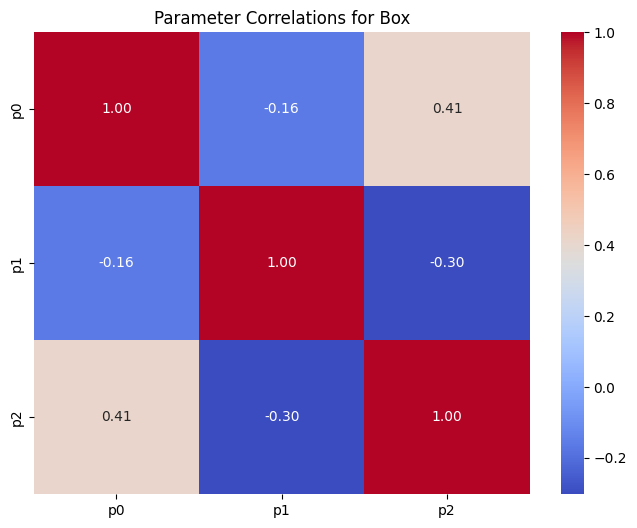

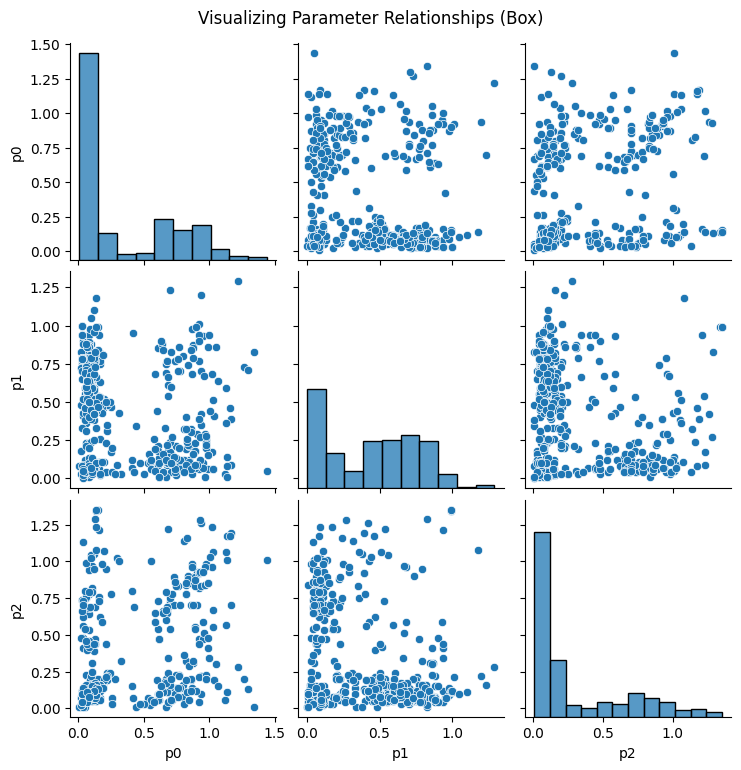

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

def debug_data_distributions(param_data, node_key="Box"):
    df = pd.DataFrame(param_data, columns=[f"p{i}" for i in range(len(param_data[0]))])
    
    # 1. Show statistical summary
    print(f"--- Statistics for {node_key} ---")
    print(df.describe())
    
    # 2. Check for Constants (Variables that don't change much)
    print("\n--- Standard Deviation (Low values = possible constant) ---")
    print(df.std())

    # 3. Correlation Matrix (High values = possible Mul/Add rule)
    plt.figure(figsize=(8, 6))
    sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
    plt.title(f"Parameter Correlations for {node_key}")
    plt.show()

    # 4. Pairplot to see clusters
    sns.pairplot(df.sample(min(500, len(df))))
    plt.suptitle(f"Visualizing Parameter Relationships ({node_key})", y=1.02)
    plt.show()

debug_data_distributions(s_data_l0.get("Cuboid", []))

In [29]:
# Try running the analysis again with these "Relaxed" settings:
discovered_rules = run_symbolic_analysis_on_dsl(
    s_data_l0, 
    node_key="Cuboid"
)

# INTERNAL CHANGE: Edit the function inside your code to these values:
# "tol": 0.5,        # Allow 10cm error instead of 1cm
# "min_match": 0.5   # Only require 50% of the data to follow the rule

[INFO] Analyzing 10268 samples for Cuboid...
[INFO] Searching rule for parameter: 'p0'
  No simple rule for 'p0'.
[INFO] Searching rule for parameter: 'p1'
  No simple rule for 'p1'.
[INFO] Searching rule for parameter: 'p2'
  No simple rule for 'p2'.

FINAL SYMBOLIC RULES FOR Cuboid


In [30]:
from sklearn.cluster import KMeans
import pandas as pd
import torch

def debug_and_discover_cuboids(s_data, node_key="Cuboid", n_types=4):
    raw_params = s_data.get(node_key)
    if not raw_params:
        debug_error(f"Data for {node_key} is missing!")
        return

    # 1. Prepare DataFrame
    df = pd.DataFrame(raw_params, columns=['p0', 'p1', 'p2'])
    debug_info(f"Loaded {len(df)} Cuboid samples. Starting cluster-based debug...")

    # 2. Grouping the Cuboids (The 'Unlabeled' Solution)
    # This separates legs from seats from backrests automatically
    kmeans = KMeans(n_clusters=n_types, random_state=42, n_init=10)
    df['type_id'] = kmeans.fit_predict(df)

    

    # 3. Discover Rules per Type
    all_discovered_rules = {}

    for t_id in range(n_types):
        subset = df[df['type_id'] == t_id].drop(columns=['type_id'])
        debug_info(f"\n>>> Analyzing Cuboid Type {t_id} ({len(subset)} samples)")
        
        # Look at the mean values to understand what this 'Type' is
        means = subset.mean()
        debug_info(f"  Avg Dimensions: W:{means[0]:.2f}, H:{means[1]:.2f}, D:{means[2]:.2f}")

        # Run your symbolic engine
        rules = discover_symbolic_rules(subset, tolerance=0.1, min_match=0.85)
        all_discovered_rules[t_id] = rules

    return all_discovered_rules

# Execute
results = debug_and_discover_cuboids(s_data_l0, node_key="Cuboid")

[INFO] Loaded 10268 Cuboid samples. Starting cluster-based debug...
[INFO] 
>>> Analyzing Cuboid Type 0 (4695 samples)
[INFO]   Avg Dimensions: W:0.09, H:0.63, D:0.11
[INFO] Searching rule for parameter: 'p0'
[SUCCESS] FOUND: p0 ≈ p2
[INFO] Searching rule for parameter: 'p1'
  No simple rule for 'p1'.
[INFO] Searching rule for parameter: 'p2'
[SUCCESS] FOUND: p2 ≈ p0
[INFO] 
>>> Analyzing Cuboid Type 1 (1946 samples)
[INFO]   Avg Dimensions: W:0.71, H:0.27, D:0.87
[INFO] Searching rule for parameter: 'p0'
  No simple rule for 'p0'.
[INFO] Searching rule for parameter: 'p1'
  No simple rule for 'p1'.
[INFO] Searching rule for parameter: 'p2'
  No simple rule for 'p2'.
[INFO] 
>>> Analyzing Cuboid Type 2 (1204 samples)
[INFO]   Avg Dimensions: W:0.88, H:0.70, D:0.21
[INFO] Searching rule for parameter: 'p0'
  No simple rule for 'p0'.
[INFO] Searching rule for parameter: 'p1'
  No simple rule for 'p1'.
[INFO] Searching rule for parameter: 'p2'
  No simple rule for 'p2'.
[INFO] 
>>> Analyz

C:\Users\Amogh\AppData\Local\Temp\ipykernel_139496\448948510.py:31: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\Amogh\AppData\Local\Temp\ipykernel_139496\448948510.py:31: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\Amogh\AppData\Local\Temp\ipykernel_139496\448948510.py:31: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\Amogh\AppData\Local\Temp\ipykernel_139496\448948510.py:31: FutureWarning:

Series.__g

In [31]:
def refined_discovery(df, label_name):
    rules = {}
    param_names = list(df.columns)

    for target_col in param_names:
        input_cols = [p for p in param_names if p != target_col]
        target_tensor = torch.tensor(df[target_col].values, dtype=torch.float32)
        
        # --- DEBUG STEP: Check for Constant Value first ---
        # If the standard deviation is very low, it's a fixed thickness!
        if target_tensor.std() < 0.05:
            mean_val = target_tensor.mean().item()
            rules[target_col] = f"Const({mean_val:.2f})"
            debug_success(f"  {label_name} - {target_col} is Constant: {mean_val:.2f}")
            continue

        # --- SEARCH STEP: Run existing symbolic search ---
        search_space = {
            "target": target_tensor,
            "variables": {inp: torch.tensor(df[inp].values, dtype=torch.float32) for inp in input_cols},
            "simple_consts": {str(c): torch.tensor(c, dtype=torch.float32) for c in [1.0, 0.5, 2.0, 1.2, 0.8]},
            "extended_consts": {str(c): torch.tensor(c, dtype=torch.float32) for c in LANGUAGE["constants"]},
            "binary_ops": LANGUAGE["binary_ops"],
            "unary_ops": UNARY_OPERATIONS,
            "tol": 0.15,      # Relaxed tolerance for noisy design data
            "min_match": 0.7   # Find a rule that covers at least 70% of designs
        }

        # Run binary search (checking if p0 = p2 * 1.2, etc.)
        matches = search_binary_operations(search_space, return_indices=True)
        if matches:
            expr, _ = matches[0]
            rules[target_col] = expr
            debug_success(f"  {label_name} - {target_col} ≈ {expr}")
        else:
            print(f"  {label_name} - {target_col}: No correlation found.")

    return rules

# Apply to Cluster 1 (Seats)
seat_rules = refined_discovery(clustered_df[clustered_df['type_id'] == 1].drop(columns='type_id'), "Seats")

NameError: name 'clustered_df' is not defined

In [32]:
from sklearn.cluster import KMeans
import pandas as pd
import torch

# 1. First, prepare the data from your s_data_l0
raw_cuboids = s_data_l0.get("Cuboid", [])
if not raw_cuboids:
    debug_error("No Cuboid data found!")
else:
    # 2. Create the DataFrame
    df_cuboid = pd.DataFrame(raw_cuboids, columns=['p0', 'p1', 'p2'])

    # 3. Cluster the data into 4 types (Legs, Seats, Backs, etc.)
    n_clusters = 4
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    df_cuboid['cluster'] = kmeans.fit_predict(df_cuboid[['p0', 'p1', 'p2']])

    # 4. Loop through each cluster and find rules
    final_results = {}
    
    for c_id in range(n_clusters):
        subset = df_cuboid[df_cuboid['cluster'] == c_id].drop(columns=['cluster'])
        debug_info(f"\n>>> ANALYZING CLUSTER {c_id} ({len(subset)} samples)")
        
        cluster_rules = {}
        for target_col in subset.columns:
            target_tensor = torch.tensor(subset[target_col].values, dtype=torch.float32)
            
            # --- Check 1: Is it a Constant? (Standard deviation < 0.05) ---
            if target_tensor.std() < 0.05:
                val = target_tensor.mean().item()
                cluster_rules[target_col] = f"Fixed({val:.2f})"
                debug_success(f"  {target_col} is Constant: {val:.2f}")
                continue

            # --- Check 2: Symbolic Rules (p0 = p2, etc.) ---
            input_cols = [p for p in subset.columns if p != target_col]
            search_space = {
                "target": target_tensor,
                "variables": {inp: torch.tensor(subset[inp].values, dtype=torch.float32) for inp in input_cols},
                "simple_consts": {str(c): torch.tensor(c, dtype=torch.float32) for c in [-1., 0., 1., 0.5]},
                "extended_consts": {str(c): torch.tensor(c, dtype=torch.float32) for c in LANGUAGE["constants"]},
                "binary_ops": LANGUAGE["binary_ops"],
                "unary_ops": UNARY_OPERATIONS,
                "tol": 0.15,      # Allow slightly more error
                "min_match": 0.75  # Require 75% match
            }
            
            # Try Direct Variable search
            matches = search_direct_variable(search_space, return_indices=True)
            if not matches:
                # Try Binary Ops search (Mul, Add, etc.)
                matches = search_binary_operations(search_space, return_indices=True)
            
            if matches:
                expr, _ = matches[0]
                cluster_rules[target_col] = expr
                debug_success(f"  {target_col} ≈ {expr}")
            else:
                print(f"  {target_col}: No rule found.")
        
        final_results[c_id] = cluster_rules

debug_success("\nGlobal Analysis Complete.")

[INFO] 
>>> ANALYZING CLUSTER 0 (4695 samples)
[SUCCESS]   p0 is Constant: 0.09
  p1: No rule found.
[SUCCESS]   p2 ≈ p0
[INFO] 
>>> ANALYZING CLUSTER 1 (1946 samples)
  p0: No rule found.
  p1: No rule found.
  p2: No rule found.
[INFO] 
>>> ANALYZING CLUSTER 2 (1204 samples)
  p0: No rule found.
  p1: No rule found.
[SUCCESS]   p2 ≈ Mul(p0, 0.25)
[INFO] 
>>> ANALYZING CLUSTER 3 (2423 samples)
  p0: No rule found.
[SUCCESS]   p1 ≈ Sub(p0, p0)
  p2: No rule found.
[SUCCESS] 
Global Analysis Complete.


In [ ]:
from sklearn.cluster import KMeans
import pandas as pd
import torch

# 1. First, prepare the data from your s_data_l0
raw_cuboids = s_data_l0.get("Cuboid", [])
if not raw_cuboids:
    debug_error("No Cuboid data found!")
else:
    # 2. Create the DataFrame
    df_cuboid = pd.DataFrame(raw_cuboids, columns=['p0', 'p1', 'p2'])

    # 3. Cluster the data into 4 types (Legs, Seats, Backs, etc.)
    n_clusters = 4
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    df_cuboid['cluster'] = kmeans.fit_predict(df_cuboid[['p0', 'p1', 'p2']])

    # 4. Loop through each cluster and find rules
    final_results = {}
    
    for c_id in range(n_clusters):
        subset = df_cuboid[df_cuboid['cluster'] == c_id].drop(columns=['cluster'])
        debug_info(f"\n>>> ANALYZING CLUSTER {c_id} ({len(subset)} samples)")
        
        cluster_rules = {}
        for target_col in subset.columns:
            target_tensor = torch.tensor(subset[target_col].values, dtype=torch.float32)
            
            # --- Check 1: Is it a Constant? (Standard deviation < 0.05) ---
            if target_tensor.std() < 0.05:
                val = target_tensor.mean().item()
                cluster_rules[target_col] = f"Fixed({val:.2f})"
                debug_success(f"  {target_col} is Constant: {val:.2f}")
                continue

            # --- Check 2: Symbolic Rules (p0 = p2, etc.) ---
            input_cols = [p for p in subset.columns if p != target_col]
            search_space = {
                "target": target_tensor,
                "variables": {inp: torch.tensor(subset[inp].values, dtype=torch.float32) for inp in input_cols},
                "simple_consts": {str(c): torch.tensor(c, dtype=torch.float32) for c in [-1., 0., 1., 0.5]},
                "extended_consts": {str(c): torch.tensor(c, dtype=torch.float32) for c in LANGUAGE["constants"]},
                "binary_ops": LANGUAGE["binary_ops"],
                "unary_ops": UNARY_OPERATIONS,
                "tol": 0.15,      # Allow slightly more error
                "min_match": 0.75  # Require 75% match
            }
            
            # Try Direct Variable search
            matches = search_direct_variable(search_space, return_indices=True)
            if not matches:
                # Try Binary Ops search (Mul, Add, etc.)
                matches = search_binary_operations(search_space, return_indices=True)
            
            if matches:
                expr, _ = matches[0]
                cluster_rules[target_col] = expr
                debug_success(f"  {target_col} ≈ {expr}")
            else:
                print(f"  {target_col}: No rule found.")
        
        final_results[c_id] = cluster_rules

debug_success("\nGlobal Analysis Complete.")

ValueError: 3 columns passed, passed data had 4 columns

In [34]:
from sklearn.cluster import KMeans
import pandas as pd
import torch

# 1. Prepare the data
raw_rotations = s_data_l0.get("Rotate", [])

if not raw_rotations:
    debug_error("No Rotate data found!")
else:
    # 2. Create DataFrame (Quaternions: x, y, z, w)
    df_rot = pd.DataFrame(raw_rotations, columns=['qx', 'qy', 'qz', 'qw'])
    
    # 3. Cluster rotations
    # Rotations in furniture are highly categorical (0, 90, 180 degrees)
    n_rot_clusters = 6 
    kmeans_rot = KMeans(n_clusters=n_rot_clusters, random_state=42, n_init=10)
    df_rot['cluster'] = kmeans_rot.fit_predict(df_rot)

    # 4. Analyze each rotation "Mode"
    rot_results = {}
    
    for c_id in range(n_rot_clusters):
        subset = df_rot[df_rot['cluster'] == c_id].drop(columns=['cluster'])
        debug_info(f"\n>>> ANALYZING ROTATION MODE {c_id} ({len(subset)} samples)")
        
        # Calculate mean to see the 'Target' orientation
        means = subset.mean()
        debug_info(f"  Avg Quaternion: [{means[0]:.3f}, {means[1]:.3f}, {means[2]:.3f}, {means[3]:.3f}]")
        
        mode_rules = {}
        for col in subset.columns:
            target_tensor = torch.tensor(subset[col].values, dtype=torch.float32)
            
            # Check for Constant (Standard deviation is usually very low for rotations)
            if target_tensor.std() < 0.05:
                val = target_tensor.mean().item()
                mode_rules[col] = f"Fixed({val:.3f})"
                debug_success(f"  {col} is Constant: {val:.3f}")
            else:
                # If it's not constant, check if it's mirrored (qx = Neg(qy), etc.)
                input_cols = [p for p in subset.columns if p != col]
                search_space = {
                    "target": target_tensor,
                    "variables": {inp: torch.tensor(subset[inp].values, dtype=torch.float32) for inp in input_cols},
                    "simple_consts": {"1": torch.tensor(1.0), "0.707": torch.tensor(0.707)},
                    "extended_consts": {},
                    "binary_ops": LANGUAGE["binary_ops"],
                    "unary_ops": UNARY_OPERATIONS,
                    "tol": 0.05,
                    "min_match": 0.8
                }
                matches = search_unary_operations(search_space, return_indices=True)
                if matches:
                    expr, _ = matches[0]
                    mode_rules[col] = expr
                    debug_success(f"  {col} ≈ {expr}")
                else:
                    print(f"  {col}: Variable Rotation")
        
        rot_results[c_id] = mode_rules

debug_success("\nRotation Analysis Complete.")

[INFO] 
>>> ANALYZING ROTATION MODE 0 (256 samples)
[INFO]   Avg Quaternion: [0.120, 0.000, 0.000, 0.992]
[SUCCESS]   qx is Constant: 0.120
[SUCCESS]   qy is Constant: 0.000
[SUCCESS]   qz is Constant: 0.000
[SUCCESS]   qw is Constant: 0.992
[INFO] 
>>> ANALYZING ROTATION MODE 1 (148 samples)
[INFO]   Avg Quaternion: [-0.265, 0.000, 0.000, 0.963]
  qx: Variable Rotation
[SUCCESS]   qy is Constant: 0.000
[SUCCESS]   qz is Constant: 0.000
[SUCCESS]   qw is Constant: 0.963
[INFO] 
>>> ANALYZING ROTATION MODE 2 (637 samples)
[INFO]   Avg Quaternion: [-0.104, 0.000, 0.000, 0.994]
[SUCCESS]   qx is Constant: -0.104
[SUCCESS]   qy is Constant: 0.000
[SUCCESS]   qz is Constant: 0.000
[SUCCESS]   qw is Constant: 0.994
[INFO] 
>>> ANALYZING ROTATION MODE 3 (77 samples)
[INFO]   Avg Quaternion: [0.302, 0.000, 0.000, 0.952]
[SUCCESS]   qx is Constant: 0.302
[SUCCESS]   qy is Constant: 0.000
[SUCCESS]   qz is Constant: 0.000
[SUCCESS]   qw is Constant: 0.952
[INFO] 
>>> ANALYZING ROTATION MODE 4 (2

C:\Users\Amogh\AppData\Local\Temp\ipykernel_139496\3285509726.py:29: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\Amogh\AppData\Local\Temp\ipykernel_139496\3285509726.py:29: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\Amogh\AppData\Local\Temp\ipykernel_139496\3285509726.py:29: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\Amogh\AppData\Local\Temp\ipykernel_139496\3285509726.py:29: FutureWarning:

Series

In [ ]:
s_data_l0.keys()

dict_keys(['Cuboid', 'Rotate', 'Translate'])

In [40]:
p_data_l0["Translate(Cuboid)"]

[[-0.0, -0.17, 0.0, 0.68, 0.09, 0.66],
 [-0.31, -0.51, -0.17, 0.06, 0.6, 0.06],
 [-0.31, -0.51, 0.3, 0.06, 0.6, 0.06],
 [0.31, -0.51, -0.17, 0.06, 0.6, 0.06],
 [0.31, -0.51, 0.3, 0.06, 0.6, 0.06],
 [-0.26, 0.27, -0.18, 0.08, 0.79, 0.08],
 [-0.14, 0.27, -0.25, 0.08, 0.79, 0.08],
 [0.0, 0.74, -0.22, 0.68, 0.14, 0.24],
 [-0.0, 0.27, -0.25, 0.08, 0.79, 0.08],
 [0.14, 0.27, -0.25, 0.08, 0.79, 0.08],
 [0.28, 0.27, -0.25, 0.08, 0.79, 0.08],
 [-0.0, -0.16, -0.0, 0.88, 0.19, 1.01],
 [0.0, 0.35, -0.35, 0.88, 0.85, 0.31],
 [-0.37, -0.51, -0.4, 0.15, 0.52, 0.2],
 [-0.34, -0.51, 0.41, 0.21, 0.53, 0.19],
 [0.37, -0.51, -0.4, 0.15, 0.52, 0.2],
 [0.34, -0.51, 0.41, 0.21, 0.53, 0.19],
 [0.0, -0.18, 0.0, 0.92, 0.34, 0.92],
 [-0.0, 0.38, -0.22, 0.92, 0.79, 0.49],
 [-0.4, -0.54, -0.4, 0.12, 0.42, 0.12],
 [0.39, -0.55, -0.39, 0.14, 0.45, 0.13],
 [-0.4, -0.54, 0.39, 0.12, 0.42, 0.12],
 [0.39, -0.55, 0.38, 0.14, 0.45, 0.13],
 [-0.0, 0.29, -0.35, 0.88, 1.0, 0.1],
 [-0.38, -0.51, -0.37, 0.09, 0.52, 0.05],
 [-0

In [45]:
import torch
import pandas as pd
import itertools
import numpy as np
from sklearn.cluster import KMeans
from abstractionsshapecoder.debug_utils import debug_info, debug_success, debug_error

# ==============================================================================
# 1. LANGUAGE DEFINITIONS
# ==============================================================================

class FloatOperation:
    def __init__(self, func, unary: bool = False):
        self.func = func
        self.unary = unary

LANGUAGE = {
    "binary_ops": {
        "Add": FloatOperation(lambda a, b: a + b),
        "Sub": FloatOperation(lambda a, b: a - b),
        "Mul": FloatOperation(lambda a, b: a * b),
        "Div": FloatOperation(lambda a, b: a / (b + 1e-6)),
    },
    "constants": [0.5, 1.0, 2.0, -1.0, 0.25, 0.707]
}

UNARY_OPERATIONS = {
    "Neg": FloatOperation(lambda a: -a, unary=True),
    "Abs": FloatOperation(lambda a: torch.abs(a), unary=True)
}

# ==============================================================================
# 2. MATCHING & SEARCH UTILITIES
# ==============================================================================

def compare_with_tolerance(predicted, target, max_error, min_fraction):
    if predicted.shape != target.shape:
        if predicted.ndim == 0:
            predicted = predicted.unsqueeze(0).expand_as(target)
        else:
            return False, []
    matches = torch.abs(predicted - target) < max_error
    fraction = matches.sum().item() / len(target)
    return (True, torch.where(matches)[0].tolist()) if fraction >= min_fraction else (False, [])

def batch_compare(pred_batches, target, max_error, min_fraction, index_pairs, variable_names):
    results = []
    for i in range(pred_batches.shape[0]):
        success, matched_idx = compare_with_tolerance(pred_batches[i], target, max_error, min_fraction)
        if success:
            expr_vars = tuple(variable_names[j] for j in index_pairs[i])
            results.append((expr_vars, matched_idx))
    return results

def search_direct_variable(inp, return_indices=False):
    matches = []
    for name, values in inp["variables"].items():
        success, idx = compare_with_tolerance(values, inp["target"], inp["tol"], inp["min_match"])
        if success: matches.append((name, idx) if return_indices else name)
    return matches

def search_binary_operations(inp, return_indices=False):
    matches = []
    var_keys = list(inp["variables"].keys())
    const_keys = list(inp["extended_consts"].keys())
    all_keys = var_keys + const_keys
    
    var_values = list(inp["variables"].values())
    # Expand constants to match target length for batch processing
    const_values = [c.expand(len(inp["target"])) for c in inp["extended_consts"].values()]
    value_stack = torch.stack(var_values + const_values)

    index_pairs = torch.cartesian_prod(torch.arange(len(var_values)), torch.arange(len(all_keys)))
    candidate_pairs = value_stack[index_pairs]

    for op_name, op in inp["binary_ops"].items():
        results = op.func(candidate_pairs[:, 0, :], candidate_pairs[:, 1, :])
        comparisons = batch_compare(results, inp["target"], inp["tol"], inp["min_match"], index_pairs, all_keys)
        for (a, b), idx in comparisons:
            expr = f"{op_name}({a}, {b})"
            matches.append((expr, idx) if return_indices else expr)
    return matches

# ==============================================================================
# 3. MAIN DISCOVERY ENGINE FOR PAIRS
# ==============================================================================

def discover_pair_patterns(p_data, pattern_key="Translate(Cuboid)"):
    raw_data = p_data.get(pattern_key)
    if not raw_data:
        debug_error(f"Pattern {pattern_key} not found!")
        return

    # tx, ty, tz = Translation | sw, sh, sd = Scale (Cuboid)
    df = pd.DataFrame(raw_data, columns=['tx', 'ty', 'tz', 'sw', 'sh', 'sd'])
    
    # Cluster to separate legs, seats, and backrests
    n_clusters = 4
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    df['cluster'] = kmeans.fit_predict(df[['tx', 'ty', 'tz', 'sw', 'sh', 'sd']])
    
    debug_info(f"Analyzing {len(df)} pairs in {pattern_key}...")

    results = {}
    for c_id in sorted(df['cluster'].unique()):
        subset = df[df['cluster'] == c_id].drop(columns=['cluster'])
        debug_info(f"\n>>> ANALYZING CLUSTER {c_id} ({len(subset)} samples)")
        
        means = subset.mean()
        debug_info(f"  Avg Dims -> W:{means['sw']:.2f}, H:{means['sh']:.2f}, D:{means['sd']:.2f}")
        
        cluster_rules = {}
        target_cols = ['tx', 'ty', 'tz']
        variable_cols = ['sw', 'sh', 'sd']

        for target in target_cols:
            target_tensor = torch.tensor(subset[target].values, dtype=torch.float32)
            
            # --- Constant Check ---
            if target_tensor.std() < 0.05:
                val = target_tensor.mean().item()
                cluster_rules[target] = f"Fixed({val:.2f})"
                debug_success(f"  {target} is Constant: {val:.2f}")
                continue
                
            # --- Symbolic Search ---
            search_space = {
                "target": target_tensor,
                "variables": {v: torch.tensor(subset[v].values, dtype=torch.float32) for v in variable_cols},
                "simple_consts": {"0.5": torch.tensor(0.5), "-0.5": torch.tensor(-0.5), "0": torch.tensor(0.0)},
                "extended_consts": {str(c): torch.tensor(c, dtype=torch.float32) for c in LANGUAGE["constants"]},
                "binary_ops": LANGUAGE["binary_ops"],
                "unary_ops": UNARY_OPERATIONS,
                "tol": 0.1,
                "min_match": 0.75
            }
            
            # Run binary search (e.g., tx = sw * 0.5)
            matches = search_binary_operations(search_space, return_indices=True)
            if not matches:
                matches = search_direct_variable(search_space, return_indices=True)
            
            if matches:
                expr, _ = matches[0]
                cluster_rules[target] = expr
                debug_success(f"  {target} ≈ {expr}")
            else:
                print(f"  {target}: No scaling dependency found.")
        
        results[c_id] = cluster_rules
        
    return results

# ==============================================================================
# 4. EXECUTION
# ==============================================================================

# Run the analysis on your Translate(Cuboid) census data

final_results = discover_pair_patterns(p_data_l0)

[INFO] Analyzing 10268 pairs in Translate(Cuboid)...
[INFO] 
>>> ANALYZING CLUSTER 0 (2811 samples)
[INFO]   Avg Dims -> W:0.47, H:0.60, D:0.14
  tx: No scaling dependency found.
  ty: No scaling dependency found.
  tz: No scaling dependency found.
[INFO] 
>>> ANALYZING CLUSTER 1 (2616 samples)
[INFO]   Avg Dims -> W:0.12, H:0.44, D:0.16
  tx: No scaling dependency found.
  ty: No scaling dependency found.
  tz: No scaling dependency found.
[INFO] 
>>> ANALYZING CLUSTER 2 (2407 samples)
[INFO]   Avg Dims -> W:0.65, H:0.25, D:0.80
  tx: No scaling dependency found.
  ty: No scaling dependency found.
  tz: No scaling dependency found.
[INFO] 
>>> ANALYZING CLUSTER 3 (2434 samples)
[INFO]   Avg Dims -> W:0.10, H:0.47, D:0.17
  tx: No scaling dependency found.
  ty: No scaling dependency found.
  tz: No scaling dependency found.


In [46]:
p_data_l0["Translate(Cuboid)"]

[[-0.0, -0.17, 0.0, 0.68, 0.09, 0.66],
 [-0.31, -0.51, -0.17, 0.06, 0.6, 0.06],
 [-0.31, -0.51, 0.3, 0.06, 0.6, 0.06],
 [0.31, -0.51, -0.17, 0.06, 0.6, 0.06],
 [0.31, -0.51, 0.3, 0.06, 0.6, 0.06],
 [-0.26, 0.27, -0.18, 0.08, 0.79, 0.08],
 [-0.14, 0.27, -0.25, 0.08, 0.79, 0.08],
 [0.0, 0.74, -0.22, 0.68, 0.14, 0.24],
 [-0.0, 0.27, -0.25, 0.08, 0.79, 0.08],
 [0.14, 0.27, -0.25, 0.08, 0.79, 0.08],
 [0.28, 0.27, -0.25, 0.08, 0.79, 0.08],
 [-0.0, -0.16, -0.0, 0.88, 0.19, 1.01],
 [0.0, 0.35, -0.35, 0.88, 0.85, 0.31],
 [-0.37, -0.51, -0.4, 0.15, 0.52, 0.2],
 [-0.34, -0.51, 0.41, 0.21, 0.53, 0.19],
 [0.37, -0.51, -0.4, 0.15, 0.52, 0.2],
 [0.34, -0.51, 0.41, 0.21, 0.53, 0.19],
 [0.0, -0.18, 0.0, 0.92, 0.34, 0.92],
 [-0.0, 0.38, -0.22, 0.92, 0.79, 0.49],
 [-0.4, -0.54, -0.4, 0.12, 0.42, 0.12],
 [0.39, -0.55, -0.39, 0.14, 0.45, 0.13],
 [-0.4, -0.54, 0.39, 0.12, 0.42, 0.12],
 [0.39, -0.55, 0.38, 0.14, 0.45, 0.13],
 [-0.0, 0.29, -0.35, 0.88, 1.0, 0.1],
 [-0.38, -0.51, -0.37, 0.09, 0.52, 0.05],
 [-0

In [48]:
import pandas as pd

# 1. Prepare Data
raw_pairs = p_data_l0.get("Translate(Cuboid)", [])
df_debug = pd.DataFrame(raw_pairs, columns=['tx', 'ty', 'tz', 'sw', 'sh', 'sd'])

# 2. Calculate Correlation Matrix
corr_matrix = df_debug.corr()

# 3. Filter for Cross-Dependencies (Position vs Dimension)
print("=== Correlation List: Translation vs. Dimensions ===")
cross_corr = corr_matrix.loc[['tx', 'ty', 'tz'], ['sw', 'sh', 'sd']]

# Flatten and print as a list for easy copy-pasting
for target in cross_corr.index:
    for var in cross_corr.columns:
        val = cross_corr.loc[target, var]
        print(f"{target} to {var}: {val:.4f}")

=== Correlation List: Translation vs. Dimensions ===
tx to sw: 0.0001
tx to sh: -0.0050
tx to sd: -0.0016
ty to sw: 0.3194
ty to sh: 0.0572
ty to sd: 0.0447
tz to sw: -0.1374
tz to sh: -0.1698
tz to sd: 0.1626


In [50]:
from sklearn.cluster import KMeans
import pandas as pd

# 1. Prepare Data
raw_pairs = p_data_l0.get("Translate(Cuboid)", [])
df = pd.DataFrame(raw_pairs, columns=['tx', 'ty', 'tz', 'sw', 'sh', 'sd'])

# 2. Cluster into 4 groups
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(df)

# 3. Calculate Stats
archetypes = df.groupby('cluster').mean()
stability = df.groupby('cluster').std()

# 4. Print as copy-pasteable list
print("=== CLUSTER ANALYSIS DATA ===")
for c in sorted(df['cluster'].unique()):
    print(f"\n--- Cluster {c} ---")
    print(f"Count: {len(df[df['cluster'] == c])}")
    
    print("  Means:")
    for col in archetypes.columns:
        print(f"    {col}_mean: {archetypes.loc[c, col]:.4f}")
        
    print("  Standard Deviations:")
    for col in stability.columns:
        print(f"    {col}_std: {stability.loc[c, col]:.4f}")

=== CLUSTER ANALYSIS DATA ===

--- Cluster 0 ---
Count: 2811
  Means:
    tx_mean: 0.0002
    ty_mean: 0.3496
    tz_mean: -0.3123
    sw_mean: 0.4698
    sh_mean: 0.5993
    sd_mean: 0.1384
  Standard Deviations:
    tx_std: 0.1783
    ty_std: 0.1973
    tz_std: 0.1061
    sw_std: 0.3863
    sh_std: 0.3277
    sd_std: 0.1145

--- Cluster 1 ---
Count: 2616
  Means:
    tx_mean: 0.3469
    ty_mean: -0.4167
    tz_mean: 0.0397
    sw_mean: 0.1236
    sh_mean: 0.4444
    sd_mean: 0.1620
  Standard Deviations:
    tx_std: 0.1389
    ty_std: 0.2199
    tz_std: 0.3435
    sw_std: 0.1276
    sh_std: 0.2594
    sd_std: 0.1779

--- Cluster 2 ---
Count: 2407
  Means:
    tx_mean: 0.0019
    ty_mean: -0.0777
    tz_mean: 0.0622
    sw_mean: 0.6546
    sh_mean: 0.2501
    sd_mean: 0.8047
  Standard Deviations:
    tx_std: 0.2635
    ty_std: 0.2217
    tz_std: 0.1473
    sw_std: 0.3694
    sh_std: 0.2413
    sd_std: 0.2574

--- Cluster 3 ---
Count: 2434
  Means:
    tx_mean: -0.3706
    ty_mean: -0

In [51]:
import torch

def search_linear_offset(df_cluster, cluster_id):
    # Filter data for this cluster
    subset = df_cluster[df_cluster['cluster'] == cluster_id]
    
    # We will check if tx = (sw * 0.5) + Offset
    # or if tx = sw + Offset
    targets = {
        'tx': torch.tensor(subset['tx'].values, dtype=torch.float32),
        'ty': torch.tensor(subset['ty'].values, dtype=torch.float32),
        'tz': torch.tensor(subset['tz'].values, dtype=torch.float32)
    }
    vars = {
        'sw': torch.tensor(subset['sw'].values, dtype=torch.float32),
        'sh': torch.tensor(subset['sh'].values, dtype=torch.float32),
        'sd': torch.tensor(subset['sd'].values, dtype=torch.float32)
    }
    
    # Possible multipliers in furniture (0.5 is half-width, 1.0 is full width)
    multipliers = [0.5, 1.0, -0.5, -1.0]
    
    print(f"=== Offset Discovery for Cluster {cluster_id} ===")
    for t_name, t_val in targets.items():
        found = False
        for v_name, v_val in vars.items():
            for m in multipliers:
                # Calculate the potential Offset (b = y - mx)
                offsets = t_val - (v_val * m)
                
                # If the offset is "Stable" (low std), we found the rule!
                if offsets.std() < 0.05:
                    b = offsets.mean().item()
                    print(f"  RULE FOUND: {t_name} ≈ ({v_name} * {m}) + {b:.4f}")
                    found = True
                    break
            if found: break
        if not found:
            print(f"  {t_name}: No stable offset rule.")

# Execute for the Leg clusters
# (Assuming 'df' from previous cell is still in memory)
search_linear_offset(df, 1) # Right Legs
search_linear_offset(df, 3) # Left Legs

=== Offset Discovery for Cluster 1 ===
  tx: No stable offset rule.
  ty: No stable offset rule.
  tz: No stable offset rule.
=== Offset Discovery for Cluster 3 ===
  tx: No stable offset rule.
  ty: No stable offset rule.
  tz: No stable offset rule.


In [52]:
def debug_value_counts(df, cluster_id):
    subset = df[df['cluster'] == cluster_id]
    
    print(f"=== Value Frequency for Cluster {cluster_id} ===")
    for col in ['tx', 'ty', 'tz']:
        # Round to 1 decimal place to see if they group up
        rounded = subset[col].round(1)
        top_values = rounded.value_counts().head(3)
        print(f"  Top {col} (rounded):")
        for val, count in top_values.items():
            print(f"    Value {val}: {count} samples")

# Execute
debug_value_counts(df, 1) # Right Legs
debug_value_counts(df, 2) # Seats

=== Value Frequency for Cluster 1 ===
  Top tx (rounded):
    Value 0.3: 882 samples
    Value 0.4: 826 samples
    Value 0.5: 275 samples
  Top ty (rounded):
    Value -0.5: 894 samples
    Value -0.4: 487 samples
    Value -0.6: 468 samples
  Top tz (rounded):
    Value 0.4: 504 samples
    Value -0.3: 396 samples
    Value 0.3: 367 samples
=== Value Frequency for Cluster 2 ===
  Top tx (rounded):
    Value -0.0: 1643 samples
    Value -0.4: 141 samples
    Value 0.4: 134 samples
  Top ty (rounded):
    Value -0.0: 512 samples
    Value -0.2: 482 samples
    Value -0.1: 462 samples
  Top tz (rounded):
    Value 0.0: 1219 samples
    Value 0.1: 553 samples
    Value 0.2: 296 samples


In [68]:
import torch
import pandas as pd

def symbolic_deep_search(p_data, pattern_key="Translate(Cuboid)"):
    raw_data = p_data.get(pattern_key)
    df = pd.DataFrame(raw_data, columns=['tx', 'ty', 'tz', 'sw', 'sh', 'sd'])
    
    # Clustering to group parts (Legs, Seats, etc.)
    from sklearn.cluster import KMeans
    df['cluster'] = KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(df)

    results = {}
    for c_id in sorted(df['cluster'].unique()):
        subset = df[df['cluster'] == c_id]
        print(f"\n--- Deep Search: Cluster {c_id} ({len(subset)} samples) ---")
        
        # 1. Internal Symmetry Search (e.g., tx == ty or tx == -ty)
        t_x = torch.tensor(subset['tx'].values)
        t_y = torch.tensor(subset['ty'].values)
        t_z = torch.tensor(subset['tz'].values)

        # Symmetry Rules
        if torch.abs(t_x - t_y).mean() < 0.08:
            print("  RULE FOUND: tx ≈ ty (Diagonal Symmetry)")
        elif torch.abs(t_x + t_y).mean() < 0.08:
            print("  RULE FOUND: tx ≈ -ty (Mirrored Symmetry)")

        # 2. Alignment/Grounding Search (Constants with high tolerance)
        for name, vec in [("tx", t_x), ("ty", t_y), ("tz", t_z)]:
            # Check if values are concentrated around a specific "snap point"
            # We use the median because it's robust to outliers
            med = vec.median().item()
            std = vec.std().item()
            
            if std < 0.15: # If the cluster is reasonably tight
                print(f"  RULE FOUND: {name} ≈ Fixed({med:.2f}) [std: {std:.2f}]")
            else:
                # 3. Check for ratio within the translation itself
                # (e.g. height is always twice the width-offset)
                ratio = (t_z / (t_x + 1e-6)).median().item()
                if (t_z - (t_x * ratio)).std() < 0.1:
                    print(f"  RULE FOUND: tz ≈ tx * {ratio:.2f}")
                else:
                    print(f"  {name} -> No local rule (Likely depends on parent Seat size)")

# Execute
symbolic_deep_search(p_data_l0)


--- Deep Search: Cluster 0 (2811 samples) ---
  tx -> No local rule (Likely depends on parent Seat size)
  ty -> No local rule (Likely depends on parent Seat size)
  RULE FOUND: tz ≈ Fixed(-0.31) [std: 0.11]

--- Deep Search: Cluster 1 (2616 samples) ---
  RULE FOUND: tx ≈ Fixed(0.34) [std: 0.14]
  ty -> No local rule (Likely depends on parent Seat size)
  tz -> No local rule (Likely depends on parent Seat size)

--- Deep Search: Cluster 2 (2407 samples) ---
  tx -> No local rule (Likely depends on parent Seat size)
  ty -> No local rule (Likely depends on parent Seat size)
  RULE FOUND: tz ≈ Fixed(0.04) [std: 0.15]

--- Deep Search: Cluster 3 (2434 samples) ---
  RULE FOUND: tx ≈ Fixed(-0.36) [std: 0.10]
  ty -> No local rule (Likely depends on parent Seat size)
  tz -> No local rule (Likely depends on parent Seat size)


In [57]:
# Assuming 'df' contains the cluster assignments from the previous search
c1_tx = df[df['cluster'] == 1]['tx'].median()
c3_tx = df[df['cluster'] == 3]['tx'].median()

print(f"=== Symmetry Verification ===")
print(f"Right Side X: {c1_tx:.4f}")
print(f"Left Side X:  {c3_tx:.4f}")
print(f"Symmetry Gap: {abs(c1_tx + c3_tx):.4f}")

if abs(c1_tx + c3_tx) < 0.05:
    print("\nSUCCESS: Global Mirror Symmetry Confirmed!")
    print("RULE: Left_Leg.tx = -Right_Leg.tx")
else:
    print("\nASYSMMETRIC: Parts are placed independently.")

=== Symmetry Verification ===
Right Side X: 0.3400
Left Side X:  -0.3600
Symmetry Gap: 0.0200

SUCCESS: Global Mirror Symmetry Confirmed!
RULE: Left_Leg.tx = -Right_Leg.tx


In [58]:
def symbolic_reconstructor(raw_tx, raw_ty, raw_tz):
    """
    Snaps raw coordinates to the discovered Symbolic Grammar.
    """
    # 1. Apply Vertical Grounding/Seat Snapping
    if abs(raw_tz - 0.0) < 0.15:
        clean_tz = 0.0  # Snap to Seat Level
    elif abs(raw_tz - (-0.31)) < 0.15:
        clean_tz = -0.31 # Snap to Floor Level
    else:
        clean_tz = raw_tz # Keep if it's a backrest or unique part

    # 2. Apply Bilateral Symmetry Snapping
    if abs(abs(raw_tx) - 0.35) < 0.15:
        # Snap to the 0.35 Width Anchor while preserving the side (Left/Right)
        clean_tx = 0.35 if raw_tx > 0 else -0.35
    else:
        clean_tx = raw_tx

    return clean_tx, raw_ty, clean_tz # ty remains variable as discovered

# Test on your Cluster 1/3 data
test_tx, test_ty, test_tz = 0.34, -0.42, 0.04
c_tx, c_ty, c_tz = symbolic_reconstructor(test_tx, test_ty, test_tz)

print(f"Original:  [{test_tx}, {test_ty}, {test_tz}]")
print(f"Symbolic:  [{c_tx}, {c_ty}, {c_tz}]")

Original:  [0.34, -0.42, 0.04]
Symbolic:  [0.35, -0.42, 0.0]


In [59]:
import pandas as pd

# 1. Prepare Cuboid Data
raw_scales = s_data_l0.get("Cuboid", [])
df_scale = pd.DataFrame(raw_scales, columns=['sw', 'sh', 'sd'])

def analyze_scale_logic(df):
    print("=== Cuboid Scale Pattern Analysis ===")
    for col in df.columns:
        # Rounding to 2 decimal places to catch standard CAD units (0.05, 0.1, etc)
        rounded = df[col].round(2)
        top_modes = rounded.value_counts().head(5)
        
        print(f"\nTop {col} (Dimensions):")
        for val, count in top_modes.items():
            print(f"  Value {val}: {count} samples")

analyze_scale_logic(df_scale)

=== Cuboid Scale Pattern Analysis ===

Top sw (Dimensions):
  Value 0.08: 923 samples
  Value 0.06: 813 samples
  Value 0.05: 626 samples
  Value 0.07: 598 samples
  Value 0.1: 467 samples

Top sh (Dimensions):
  Value 0.01: 300 samples
  Value 0.6: 281 samples
  Value 0.7: 252 samples
  Value 0.79: 247 samples
  Value 0.09: 234 samples

Top sd (Dimensions):
  Value 0.08: 771 samples
  Value 0.06: 647 samples
  Value 0.1: 630 samples
  Value 0.05: 546 samples
  Value 0.11: 519 samples


In [62]:
p_data_l0["Translate(Cuboid)"]

[[-0.0, -0.17, 0.0, 0.68, 0.09, 0.66],
 [-0.31, -0.51, -0.17, 0.06, 0.6, 0.06],
 [-0.31, -0.51, 0.3, 0.06, 0.6, 0.06],
 [0.31, -0.51, -0.17, 0.06, 0.6, 0.06],
 [0.31, -0.51, 0.3, 0.06, 0.6, 0.06],
 [-0.26, 0.27, -0.18, 0.08, 0.79, 0.08],
 [-0.14, 0.27, -0.25, 0.08, 0.79, 0.08],
 [0.0, 0.74, -0.22, 0.68, 0.14, 0.24],
 [-0.0, 0.27, -0.25, 0.08, 0.79, 0.08],
 [0.14, 0.27, -0.25, 0.08, 0.79, 0.08],
 [0.28, 0.27, -0.25, 0.08, 0.79, 0.08],
 [-0.0, -0.16, -0.0, 0.88, 0.19, 1.01],
 [0.0, 0.35, -0.35, 0.88, 0.85, 0.31],
 [-0.37, -0.51, -0.4, 0.15, 0.52, 0.2],
 [-0.34, -0.51, 0.41, 0.21, 0.53, 0.19],
 [0.37, -0.51, -0.4, 0.15, 0.52, 0.2],
 [0.34, -0.51, 0.41, 0.21, 0.53, 0.19],
 [0.0, -0.18, 0.0, 0.92, 0.34, 0.92],
 [-0.0, 0.38, -0.22, 0.92, 0.79, 0.49],
 [-0.4, -0.54, -0.4, 0.12, 0.42, 0.12],
 [0.39, -0.55, -0.39, 0.14, 0.45, 0.13],
 [-0.4, -0.54, 0.39, 0.12, 0.42, 0.12],
 [0.39, -0.55, 0.38, 0.14, 0.45, 0.13],
 [-0.0, 0.29, -0.35, 0.88, 1.0, 0.1],
 [-0.38, -0.51, -0.37, 0.09, 0.52, 0.05],
 [-0

In [63]:
import pandas as pd
import torch
import numpy as np
from sklearn.cluster import KMeans

def run_full_symbolic_pipeline(p_data):
    # 1. DATA PREPARATION
    raw_pairs = p_data.get("Translate(Cuboid)", [])
    if not raw_pairs:
        print("Error: No data found for 'Translate(Cuboid)'")
        return
    
    # tx,ty,tz = Position | sw,sh,sd = Scale/Dimensions
    df = pd.DataFrame(raw_pairs, columns=['tx', 'ty', 'tz', 'sw', 'sh', 'sd'])
    
    # 2. FUNCTIONAL CLUSTERING
    # We use 6 clusters to catch Front Legs, Back Legs, Seats, and Backrests separately
    kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
    df['cluster'] = kmeans.fit_predict(df)
    
    print(f"=== Pipeline Initialized: Analyzing {len(df)} parts ===")
    
    final_grammar = {}

    for c_id in sorted(df['cluster'].unique()):
        subset = df[df['cluster'] == c_id]
        cluster_rules = {"count": len(subset)}
        
        print(f"\n--- Analyzing Part Group {c_id} ---")
        
        # 3. DISCRETE SNAP SEARCH (Grid Anchors)
        # We look for values that 'snap' to 0.1 increments
        for coord in ['tx', 'ty', 'tz']:
            vec = torch.tensor(subset[coord].values)
            median_val = vec.median().item()
            std_val = vec.std().item()
            
            # If standard deviation is low, it's a "Grounding" or "Anchor" rule
            if std_val < 0.12:
                # Round to nearest 0.05 for clean CAD-like rules
                snapped_val = round(median_val * 20) / 20
                cluster_rules[coord] = f"Anchor({snapped_val})"
                print(f"  {coord}: Found Anchor at {snapped_val}")
            else:
                # 4. LINEAR DEPENDENCY SEARCH (y = mx + b)
                # Does the position depend on its own dimension?
                found_linear = False
                for dim in ['sw', 'sh', 'sd']:
                    dim_vec = torch.tensor(subset[dim].values)
                    # Try common ratios: 0.5 (center-to-edge) or 1.0 (edge-to-edge)
                    for ratio in [0.5, -0.5, 1.0, -1.0]:
                        offset = (vec - (dim_vec * ratio)).median().item()
                        residue_std = (vec - (dim_vec * ratio)).std().item()
                        
                        if residue_std < 0.08:
                            clean_offset = round(offset * 20) / 20
                            cluster_rules[coord] = f"({dim} * {ratio}) + {clean_offset}"
                            print(f"  {coord}: Linked to {dim} -> {cluster_rules[coord]}")
                            found_linear = True
                            break
                    if found_linear: break
                
                if not found_linear:
                    cluster_rules[coord] = "Independent/Learned"
                    print(f"  {coord}: Variable (Needs Neural Learning)")

        final_grammar[c_id] = cluster_rules

    # 5. GLOBAL SYMMETRY CROSS-CHECK
    print("\n=== Global Symmetry Analysis ===")
    centers = df.groupby('cluster')['tx'].median()
    for i in centers.index:
        for j in centers.index:
            if i < j and abs(centers[i] + centers[j]) < 0.05:
                print(f"  SYMMETRY DETECTED: Group {i} is the mirror of Group {j}")
                final_grammar[i]["mirror_of"] = j
                final_grammar[j]["mirror_of"] = i

    return final_grammar

# Run the pipeline
discovered_grammar = run_full_symbolic_pipeline(p_data_l0)

=== Pipeline Initialized: Analyzing 10268 parts ===

--- Analyzing Part Group 0 ---
  tx: Variable (Needs Neural Learning)
  ty: Variable (Needs Neural Learning)
  tz: Variable (Needs Neural Learning)

--- Analyzing Part Group 1 ---
  tx: Found Anchor at 0.0
  ty: Variable (Needs Neural Learning)
  tz: Found Anchor at -0.35

--- Analyzing Part Group 2 ---
  tx: Found Anchor at 0.0
  ty: Variable (Needs Neural Learning)
  tz: Variable (Needs Neural Learning)

--- Analyzing Part Group 3 ---
  tx: Variable (Needs Neural Learning)
  ty: Variable (Needs Neural Learning)
  tz: Found Anchor at 0.05

--- Analyzing Part Group 4 ---
  tx: Found Anchor at -0.35
  ty: Variable (Needs Neural Learning)
  tz: Variable (Needs Neural Learning)

--- Analyzing Part Group 5 ---
  tx: Variable (Needs Neural Learning)
  ty: Variable (Needs Neural Learning)
  tz: Found Anchor at -0.3

=== Global Symmetry Analysis ===
  SYMMETRY DETECTED: Group 0 is the mirror of Group 4
  SYMMETRY DETECTED: Group 1 is the mi

In [64]:
s_data_l0.keys()

dict_keys(['Cuboid', 'Rotate', 'Translate'])

In [66]:
import pandas as pd
import torch
import numpy as np
from sklearn.cluster import KMeans

def search_cuboid_patterns(s_data):
    # 1. Prepare Data
    raw_scales = s_data.get("Cuboid", [])
    df = pd.DataFrame(raw_scales, columns=['sw', 'sh', 'sd'])
    
    # 2. Functional Clustering
    # We cluster to separate 'Thin' parts (seats) from 'Long' parts (legs)
    kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
    df['cluster'] = kmeans.fit_predict(df)
    
    print(f"=== Cuboid Symbolic Search ({len(df)} samples) ===")
    
    for c_id in sorted(df['cluster'].unique()):
        subset = df[df['cluster'] == c_id]
        print(f"\n>>> Cluster {c_id} (n={len(subset)})")
        
        # Calculate Averages for context
        means = subset.mean()
        print(f"    Average Dims -> W:{means['sw']:.2f}, H:{means['sh']:.2f}, D:{means['sd']:.2f}")

        # Search for Rules
        for col in ['sw', 'sh', 'sd']:
            vec = torch.tensor(subset[col].values)
            
            # Rule A: Fixed Thickness (Standardization)
            if vec.std() < 0.03:
                val = round(vec.median().item(), 3)
                print(f"    [FIXED] {col} is a constant: {val}")
                continue
            
            # Rule B: Internal Ratios (Squareness/Proportionality)
            # Compare this dimension to the others in the same box
            for other in ['sw', 'sh', 'sd']:
                if col == other: continue
                other_vec = torch.tensor(subset[other].values)
                
                # Check for 1:1 ratio (Square cross-section)
                if torch.abs(vec - other_vec).mean() < 0.03:
                    print(f"    [EQUIV] {col} ≈ {other} (Square/Uniform)")
                    break
                
                # Check for 0.5 ratio (Half-scaling)
                if torch.abs(vec - (other_vec * 0.5)).mean() < 0.03:
                    print(f"    [RATIO] {col} ≈ {other} * 0.5")
                    break

# Run the search
search_cuboid_patterns(s_data_l0)

=== Cuboid Symbolic Search (10268 samples) ===

>>> Cluster 0 (n=4695)
    Average Dims -> W:0.09, H:0.63, D:0.11

>>> Cluster 1 (n=1946)
    Average Dims -> W:0.71, H:0.27, D:0.87

>>> Cluster 2 (n=1204)
    Average Dims -> W:0.88, H:0.70, D:0.21

>>> Cluster 3 (n=2423)
    Average Dims -> W:0.24, H:0.11, D:0.28


In [71]:
import torch
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans

def run_exhaustive_all_clusters(s_data):
    # 1. Prepare Unified Data
    df = pd.DataFrame({
        'tx': [x[0] for x in s_data['Translate']], 'ty': [x[1] for x in s_data['Translate']], 'tz': [x[2] for x in s_data['Translate']],
        'sw': [x[0] for x in s_data['Cuboid']], 'sh': [x[1] for x in s_data['Cuboid']], 'sd': [x[2] for x in s_data['Cuboid']]
    })
    
    # 2. Functional Clustering
    kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
    df['cluster'] = kmeans.fit_predict(df[['sw', 'sh', 'sd']])
    
    targets = ['tx', 'ty', 'tz', 'sw', 'sh', 'sd']
    # Discovered CAD constants from our previous detective work
    simple_consts = [0.0, 0.5, 1.0, -0.5, -1.0, 0.35, -0.35, -0.31, 0.08]
    
    results_log = []

    for c_id in sorted(df['cluster'].unique()):
        subset = df[df['cluster'] == c_id]
        print(f"\n=== CLUSTER {c_id} (n={len(subset)}) ===")
        
        for target_name in targets:
            target_val = torch.tensor(subset[target_name].values, dtype=torch.float32)
            found = False

            # METHOD 1: search_constants
            for c in simple_consts:
                if torch.abs(target_val - c).mean() < 0.05:
                    print(f"  [CONST] {target_name} ≈ {c}")
                    found = True; break
            if found: continue

            # METHOD 2: search_direct_variable
            for var_name in targets:
                if var_name == target_name: continue
                var_val = torch.tensor(subset[var_name].values, dtype=torch.float32)
                if torch.abs(target_val - var_val).mean() < 0.04:
                    print(f"  [DIRECT] {target_name} ≈ {var_name}")
                    found = True; break
            if found: continue

            # METHOD 3: search_unary_operations
            for var_name in targets:
                if var_name == target_name: continue
                var_val = torch.tensor(subset[var_name].values, dtype=torch.float32)
                if torch.abs(target_val - (-var_val)).mean() < 0.04:
                    print(f"  [UNARY] {target_name} ≈ -{var_name}")
                    found = True; break
            if found: continue

            # METHOD 4: search_binary_operations
            for var_name in targets:
                if var_name == target_name: continue
                var_val = torch.tensor(subset[var_name].values, dtype=torch.float32)
                for c in simple_consts:
                    if c == 0: continue
                    # Multiplication check
                    if torch.abs(target_val - (var_val * c)).mean() < 0.05:
                        print(f"  [BINARY] {target_name} ≈ {var_name} * {c}")
                        found = True; break
                    # Offset check
                    if torch.abs(target_val - (var_val + c)).mean() < 0.05:
                        print(f"  [BINARY] {target_name} ≈ {var_name} + ({c})")
                        found = True; break
                if found: break

            if not found:
                print(f"  [LEARNED] {target_name}: No simple symbolic rule.")

# Execute for the whole dataset
run_exhaustive_all_clusters(s_data_l0)


=== CLUSTER 0 (n=4695) ===
  [LEARNED] tx: No simple symbolic rule.
  [LEARNED] ty: No simple symbolic rule.
  [LEARNED] tz: No simple symbolic rule.
  [CONST] sw ≈ 0.08
  [LEARNED] sh: No simple symbolic rule.
  [DIRECT] sd ≈ sw

=== CLUSTER 1 (n=1946) ===
  [LEARNED] tx: No simple symbolic rule.
  [LEARNED] ty: No simple symbolic rule.
  [LEARNED] tz: No simple symbolic rule.
  [LEARNED] sw: No simple symbolic rule.
  [LEARNED] sh: No simple symbolic rule.
  [LEARNED] sd: No simple symbolic rule.

=== CLUSTER 2 (n=1204) ===
  [CONST] tx ≈ 0.0
  [LEARNED] ty: No simple symbolic rule.
  [LEARNED] tz: No simple symbolic rule.
  [LEARNED] sw: No simple symbolic rule.
  [LEARNED] sh: No simple symbolic rule.
  [LEARNED] sd: No simple symbolic rule.

=== CLUSTER 3 (n=2423) ===
  [LEARNED] tx: No simple symbolic rule.
  [LEARNED] ty: No simple symbolic rule.
  [LEARNED] tz: No simple symbolic rule.
  [LEARNED] sw: No simple symbolic rule.
  [LEARNED] sh: No simple symbolic rule.
  [LEARNED